# MNIST utility experiment

Thin notebook for running the same sparse-train augmentation diagnostic on MNIST. Implementation lives in `rankgen_utility_experiment/`.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from rankgen_utility_experiment.experiment import ExperimentConfig, run_on_dataset, summarize, plot_metric_bars, label_metric_columns
from rankgen_utility_experiment.mnist import MnistConfig, make_mnist_dataset, plot_mnist_samples, plot_mnist_umap

k = 5
include_noise_model = False

mnist_config = MnistConfig(
    seed=7,
    train_per_class=65,
    test_per_class=800,
    oracle_per_class=800,
    classes=tuple([3,8]), #[4,7,9] [3,5,8]
)

experiment_config = ExperimentConfig(
    seed=mnist_config.seed,
    generated_per_class=800,
    generator_latent_components=6,
    smote_neighbors=k,
    smote_lambda=0.5,
    transfer_ab_neighbors=k,
    transfer_bc_neighbors=k,
    transfer_lambda=1.5,
    rf_n_estimators=50,
    rf_max_depth=None,
    rf_min_samples_leaf=4,
    rf_max_features="sqrt",
    rf_max_real_samples=1_000,
    rf_n_jobs=-1,
)

In [2]:
data = make_mnist_dataset(mnist_config)
data.x_train.shape, data.x_test.shape, data.x_oracle.shape

((130, 784), (1600, 784), (1600, 784))

In [3]:
data, generated, result = run_on_dataset(
    experiment_config,
    data,
    include_noise_model=include_noise_model,
)
label_metric_columns(result).round(4)

,seed,generator,n_generated,quality ↑,utility ↑,indistinguishability ↑,similarity ↑,baseline_accuracy ↑,generated_only_accuracy ↑,real_augmented_accuracy ↑,generated_augmented_accuracy ↑,real_augmentation_gain ↑,generated_augmentation_gain ↑,fid_to_oracle ↓,precision ↑,recall ↑,distinguishability_accuracy ↓
0,7,SMOTE interpolation,1600,0.9934,0.0204,0.0,0.0000,0.9538,0.9475,0.9844,0.9544,0.0306,0.0006,26.3612,0.9819,0.0,1.0
1,7,Transferred local differences,1600,0.9921,0.1429,0.0,0.0058,0.9538,0.9462,0.9844,0.9581,0.0306,0.0044,28.4209,0.7794,0.0,1.0


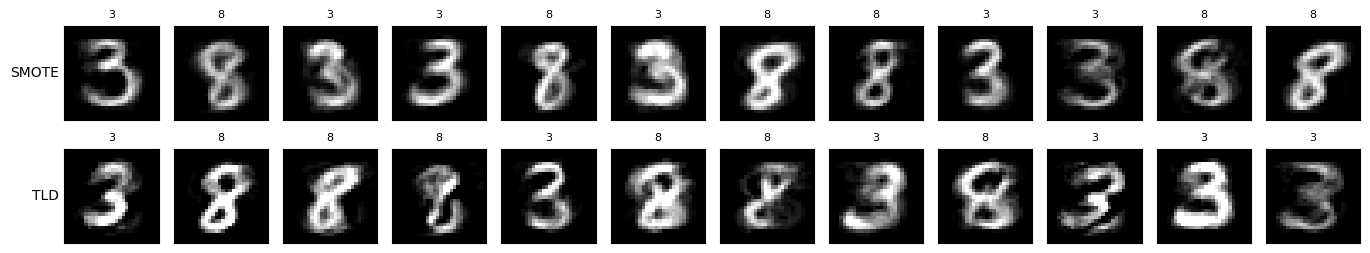

In [4]:
plot_mnist_samples(generated, n_per_generator=12, seed=None);

/Users/fabriziocosta/miniconda3/envs/py311/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


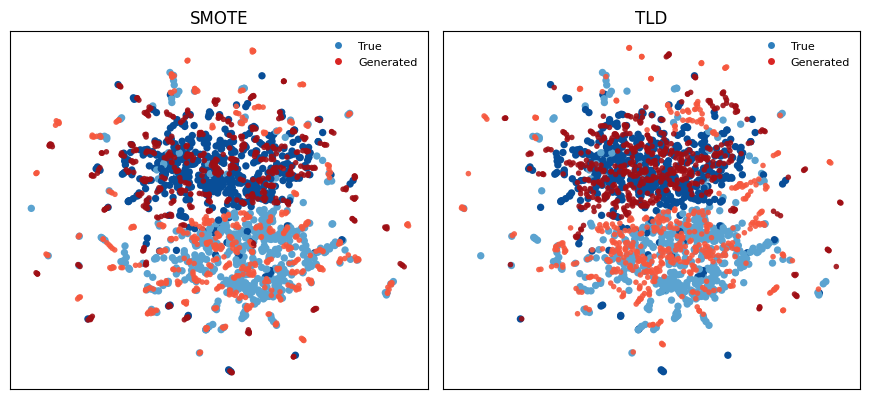

In [5]:
plot_mnist_umap(
    data,
    generated,
    max_real=1_000,
    max_generated_per_generator=1_000,
    seed=mnist_config.seed,
    n_neighbors=3,
    min_dist=0.75
);

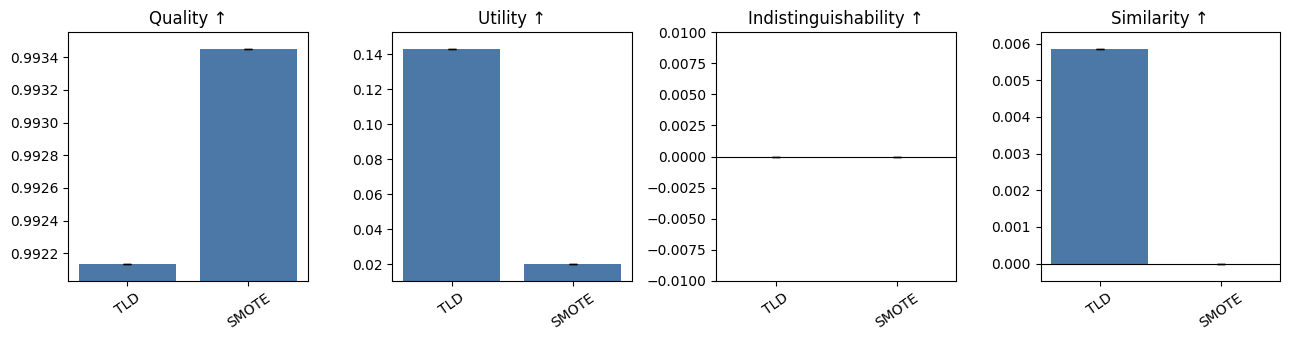

In [6]:
plot_metric_bars(result);

`test_per_class` is the held-out set for downstream accuracy and utility gain. `oracle_per_class` is a separate real sample used for diagnostics such as quality, FID-like distance, precision/recall, and real-vs-generated distinguishability.